<a href="https://colab.research.google.com/github/Mazen-Morsy/ML-Final/blob/main/Heart_Disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [105]:
df = pd.read_csv("/content/heart_patients_dirty_dataset.csv")


In [106]:
df.head()

,Patient_ID,Age,Gender,Chest_Pain_Type,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Exercise_Induced_Angina,Heart_Disease
0,524.0,87.0,NaN,NaN,151.343081,162.378238,162.287641,2.801430,Yes,zero
1,603.0,66.0,male,NaN,101.214098,218.380992,155.846201,0.182318,No,zero
2,527.0,87.0,FEMALE,Atypical Angina,150.354093,248.765623,195.335192,0.875113,yes,1
3,32.0,87.0,FEMALE,Non-Anginal Pain,124.865389,NaN,180.730370,0.300505,yes,NaN
4,617.0,45.0,NaN,Typical Angina,112.437303,211.572296,121.968906,NaN,No,one


In [107]:
df.shape

(1020, 10)

In [108]:
df.isnull().sum()

,0
Patient_ID,15
Age,15
Gender,216
Chest_Pain_Type,222
Resting_BP_mmHg,16
Cholesterol_mg/dl,15
Max_Heart_Rate,16
ST_Depression,25
Exercise_Induced_Angina,219
Heart_Disease,238


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1005 non-null   float64
 1   Age                      1005 non-null   object 
 2   Gender                   804 non-null    object 
 3   Chest_Pain_Type          798 non-null    object 
 4   Resting_BP_mmHg          1004 non-null   float64
 5   Cholesterol_mg/dl        1005 non-null   float64
 6   Max_Heart_Rate           1004 non-null   float64
 7   ST_Depression            995 non-null    float64
 8   Exercise_Induced_Angina  801 non-null    object 
 9   Heart_Disease            782 non-null    object 
dtypes: float64(5), object(5)
memory usage: 79.8+ KB


In [110]:
df.describe()

,Patient_ID,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression
count,1005.000000,1004.000000,1005.000000,1004.000000,995.000000
mean,501.477612,121.967621,208.588632,149.889774,0.988759
std,288.663393,18.300116,85.665783,26.977657,0.989915
min,1.000000,74.707318,50.443201,74.809192,-2.176704
25%,255.000000,110.589693,164.548952,132.826732,0.343811
50%,501.000000,120.502121,201.722051,149.947067,0.982994
75%,752.000000,130.897693,234.770124,166.470884,1.655162
max,1000.000000,237.905224,976.733483,297.129217,4.112910


In [111]:
df.describe(include='object')

,Age,Gender,Chest_Pain_Type,Exercise_Induced_Angina,Heart_Disease
count,1005,804,798,801,782
unique,61,4,4,4,4
top,87.0,male,Asymptomatic,Yes,zero
freq,28,212,225,236,207


In [112]:
categorical_cols=list(df.select_dtypes(include=object).columns)
categorical_cols

['Age',
 'Gender',
 'Chest_Pain_Type',
 'Exercise_Induced_Angina',
 'Heart_Disease']

In [113]:
numerical_cols=list(df.select_dtypes(include=np.number).columns)
numerical_cols

['Patient_ID',
 'Resting_BP_mmHg',
 'Cholesterol_mg/dl',
 'Max_Heart_Rate',
 'ST_Depression']

In [114]:
df['Gender'].unique()

array([nan, 'male', 'FEMALE', 'Male', 'Female'], dtype=object)

In [115]:
df['Gender'] = df['Gender' ].str.strip()
df['Gender'] = df['Gender'].str. lower()
df['Gender'].unique()


array([nan, 'male', 'female'], dtype=object)

In [116]:
df[ 'Chest_Pain_Type'].unique()

array([nan, 'Atypical Angina', 'Non-Anginal Pain', 'Typical Angina',
       'Asymptomatic'], dtype=object)

In [117]:
df[ 'Exercise_Induced_Angina'].unique()

array(['Yes', 'No', 'yes', nan, 'NO'], dtype=object)

In [118]:
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina' ].str.strip()
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina'].str. lower()
df['Exercise_Induced_Angina'].unique()


array(['yes', 'no', nan], dtype=object)

In [119]:
df['Heart_Disease'].unique()

array(['zero', '1', nan, 'one', '0'], dtype=object)

In [120]:
df['Heart_Disease'].replace({'zero':'0' , 'one':'1'})
df['Heart_Disease'].unique()




array(['zero', '1', nan, 'one', '0'], dtype=object)

In [121]:
df['Heart_Disease'] = pd.to_numeric(df['Heart_Disease'], errors='coerce') #converting heart disease from object to numeric

In [122]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') #converting object from object to numeric

In [123]:
df.drop(columns=['Patient_ID'],inplace=True)

In [124]:
df.describe()

,Age,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Heart_Disease
count,995.000000,1004.000000,1005.000000,1004.000000,995.000000,369.000000
mean,60.128643,121.967621,208.588632,149.889774,0.988759,0.531165
std,17.419188,18.300116,85.665783,26.977657,0.989915,0.499705
min,30.000000,74.707318,50.443201,74.809192,-2.176704,0.000000
25%,45.500000,110.589693,164.548952,132.826732,0.343811,0.000000
50%,61.000000,120.502121,201.722051,149.947067,0.982994,1.000000
75%,76.000000,130.897693,234.770124,166.470884,1.655162,1.000000
max,89.000000,237.905224,976.733483,297.129217,4.112910,1.000000


In [125]:
numerical_cols=list(df.select_dtypes(include=np.number).columns)
numerical_cols

['Age',
 'Resting_BP_mmHg',
 'Cholesterol_mg/dl',
 'Max_Heart_Rate',
 'ST_Depression',
 'Heart_Disease']

In [126]:
df[df['ST_Depression'] < 0]['ST_Depression'].value_counts()

,count
ST_Depression,
-0.271919,2
-0.445205,2
-0.064220,2
-0.497258,2
-0.130179,2
...,...
-0.055108,1
-0.290561,1
-0.190408,1


In [127]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #replacing the none values of age with the mean

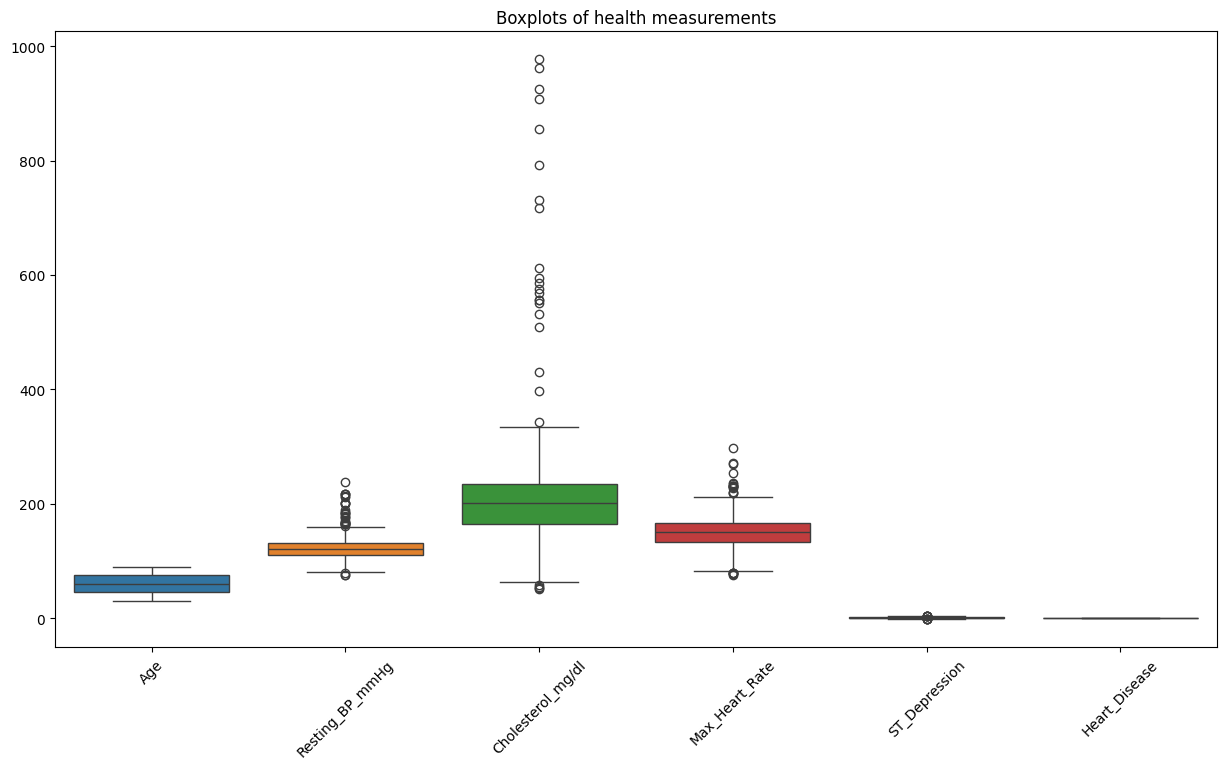

In [128]:
#outlier detection
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title('Boxplots of health measurements')

plt.show()

In [129]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #replacing the none values of age with the mean

In [130]:
df['Resting_BP_mmHg'] = df['Resting_BP_mmHg'].fillna(df['Resting_BP_mmHg'].median()) #replacing the none values with the median

In [131]:
df['Cholesterol_mg/dl'] = df['Cholesterol_mg/dl'].fillna(df['Cholesterol_mg/dl'].median()) #replacing the none values with the median

In [132]:
df['Max_Heart_Rate'] = df['Max_Heart_Rate'].fillna(df['Max_Heart_Rate'].median()) #replacing the none values with the median

In [133]:
df['ST_Depression'] = df['ST_Depression'].fillna(df['ST_Depression'].median()) #replacing the none values with the median

In [134]:
df.duplicated().sum()


np.int64(20)

In [135]:
df = df.drop_duplicates()